In [89]:
import matplotlib.pyplot as plt
from qutip import *
import numpy as np
import scipy.integrate as integrate
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

In [43]:
### SET UP FOR A THREE LEVEL SYSTEM
ground = Qobj([[1],[0],[0]])  
storage = Qobj([[0],[1],[0]]) 
excited = Qobj([[0],[0],[1]]) 

sigma_ge = Qobj([[0,0,0],[0,0,0],[1,0,0]])  # |e><g| (transition from g to e)
sigma_eg = Qobj([[0,0,1],[0,0,0],[0,0,0]])  # |g><e| (transition from e to g)

sigma_se = Qobj([[0,0,0],[0,0,0],[0,1,0]])  # |e><s| (transition from s to e)
sigma_es = Qobj([[0,0,0],[0,0,1],[0,0,0]])  # |s><e| (transition from e to s)

sigma_gs = Qobj([[0,0,0],[1,0,0],[0,0,0]])  # |s><g| (transition from g to s)
sigma_sg = Qobj([[0,1,0],[0,0,0],[0,0,0]])  # |g><s| (transition from s to g)

## Hamiltonian
The Hamiltonian for the three-level system is

$$ \hat{H} = g_{se} (\hat{\textbf{a}}_{se}(t)\hat{\sigma}_{se}+ \hat{\textbf{a}}_{se}^\dagger(t)\hat{\sigma}_{es}) +
g_{ge} (\hat{\textbf{a}}_{ge}(t)\hat{\sigma}_{ge} + \hat{\textbf{a}}_{ge}^\dagger(t)\hat{\sigma}_{eg})
$$

The $\hat{\textbf{a}}_{se}(t)$ corresponds to the input pulse (signal), whereas $\hat{\textbf{a}}_{ge}(t)$ corresponds to the control pulse we apply. Again, we seem to ultimately ignore the vacuum field after expectation valuing.  The couplings $g_{se}, g_{ge}$ should be determined by the medium (constants). We will denote $\beta(t)$ and $\alpha(t)$ as the expectation value of $\hat{\textbf{a}}_{ge}(t)$ and  $\hat{\textbf{a}}_{se}(t)$ respectively. After expectation valuing everything:

$$ \hat{H} = g_{se} (\alpha(t)\hat{\sigma}_{se}+ \alpha^\dagger(t)\hat{\sigma}_{es}) +
g_{ge} (\beta(t)\hat{\sigma}_{ge} + \beta^\dagger(t)\hat{\sigma}_{eg}) $$

Assuming the input signal is real,

$$ \hat{H} = g_{se} \alpha(t)(\hat{\sigma}_{se}+ \hat{\sigma}_{es}) +
g_{ge} (\beta(t)\hat{\sigma}_{ge} + \beta^\dagger(t)\hat{\sigma}_{eg}) $$

The decay terms are now given by:
$$  \mathbf{L} = \begin{bmatrix} -
{g_{se}^*}\hat{\sigma}_{es},
{g_{ge}^*}
\hat{\sigma}_{eg}
\end{bmatrix} $$

This is different from the two-level system: our vacuum Rabi frequency is defined by $g$ but here, we have a constant vacuum Rabi frequency defined by $g_{ge}$, for example. 

Note that the Lindblad term does not include a signal or coupling term: the signal does not affect the dynamics of the Hamiltonian. when you adiabatically eliminate the excited state, the effective Rabi frequency between gs state appears (why?). In our current simulation, there is no adiabatic elimination, so we do not include the signal in the Lindblad terms. After the adiabatic elimination, signal shows up in the Lindblad terms. 

To perform a test of whether or not this will work, set $g_{ge}$ equal to $0$ and compare the results with a two-level system


Let's continue with this for now as before and just simulate.

In [134]:
T = 10 # total time (input pulse "duration")
N = 5000 # number of time steps

g_se = 1
g_ge = 1 # Set this to 0 to simulate TLS with constant coupling

mu, sigma = 2.5, 0.5 # defined for a Gaussian input pulse

# Returned area-normalized Gaussian
def gaussian(mu, sigma, t):
    return np.sqrt(1/(sigma*np.sqrt(np.pi))) * np.exp(-((t-mu)**2) / (2*sigma**2))

### INPUT COHERENT STATE
def alpha_in(t):
    a = 0.1 # small amplitude
    return a*(gaussian(mu, sigma, t)) # + np.random.normal(0, sigma*0.01, 1)) # Gaussian input

### TEMPLATE FUNCTION (k(t) = template at time t)
def k(t):
    return gaussian(mu, sigma, t) # for perfectly overlapping Gaussian template (change mu to diff values for time shift)
    #return gaussian(mu, sigma, t) * np.sin(t-mu) # for orthogonal template 

### COUPLING FUNCTION (g(t) = coupling strength between atom and light at time t)
def g(t):
    integral_value, _ = integrate.quad(lambda x: np.abs(k(x))**2, 0, t) # Denominator -inf to t
    return k(t) / np.sqrt(integral_value) if integral_value > 0 else 0

In [135]:
time = np.linspace(0, T, N)
alpha = alpha_in(time) # input signal

g_vals, k_vals = [], []
for t in time: 
    g_vals.append(g(t))
    k_vals.append(k(t))

g_vals_smoothed = gaussian_filter1d(g_vals, sigma=10)  # Apply Gaussian smoothing
def g_smoothed(t):
    if t == time[0]: return 0
    else:            return np.interp(t, time, g_vals_smoothed)  # Interpolate smoothed g values

$$ \hat{H} = g_{se} \alpha(t)(\hat{\sigma}_{se}+ \hat{\sigma}_{es}) +
g_{ge} (\beta(t)\hat{\sigma}_{ge} + \beta^\dagger(t)\hat{\sigma}_{eg}) $$

In [136]:
### ---------------------------- HAMILTONIAN ---------------------------------
H_signal = sigma_se + sigma_es
H_coupling = sigma_ge
H_coupling_dag = sigma_eg

def H_signal_coeff(t, args): 
    return g_se * alpha_in(t) 

def H_coupling_coeff(t, args):
    return g_ge * g(t)

def H_coupling_dag_coeff(t, args):
    return g_ge * np.conjugate(g(t))

H = [[H_signal, H_signal_coeff], [H_coupling, H_coupling_coeff], [H_coupling_dag, H_coupling_dag_coeff]] # Final Hamiltonian 
print(H)

[[Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]], <function H_signal_coeff at 0x000001E410AFFEB0>], [Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0. 0. 0.]
 [0. 0. 0.]
 [1. 0. 0.]], <function H_coupling_coeff at 0x000001E47C982F80>], [Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0. 0. 1.]
 [0. 0. 0.]
 [0. 0. 0.]], <function H_coupling_dag_coeff at 0x000001E47C981A20>]]


In [137]:
# ------------------DISSIPATION OPERATORES (collapse operators)-----------------
def col_coeff_es(t, args): 
    return -np.conjugate(g_se) * 1 # (for TLS test)
    #return -np.conjugate(g_se) *  np.conjugate(g_smoothed(t)) 

def col_coeff_eg(t, args): 
    return -np.conjugate(g_ge) * np.conjugate(g_smoothed(t))

#c_op_list = [[sigma_es, col_coeff_es]]  # time-dependent collapse term for TLS test
#c_op_list = [[sigma_es, col_coeff_es], [sigma_eg, col_coeff_eg]]  # time-dependent collapse term
c_op_list = [] # No dissipation

### SIMULATE: starting from the ground state, solve Schrodinger equation
psi0 = ground # |g> 
#psi0 = storage # |s> (for testing TLS)
result = mesolve(H, psi0, time, c_op_list) 

In [138]:
###--------------------- RESULTS ---------------------------
prob_g = [] # probability of finding state in |g>
prob_s = [] # probability of finding state in |s>
prob_e = [] # probability of finding state in |e>

S = [] # expectation value of |g><s|

for i in range(0, len(result.states)):
    # No dissipation (result outputs states) 
    p_g, p_s, p_e = abs(result.states[i][0])**2, abs(result.states[i][1])**2, abs(result.states[i][2])**2
    
    # With dissipation (result outputs density operators)
    #p_g, p_s, p_e = result.states[i][0][0], result.states[i][1][1], result.states[i][2][2]
    
    prob_g = np.append(prob_g, p_g)
    prob_s = np.append(prob_s, p_s)
    prob_e = np.append(prob_e, p_e)

    #S = np.append(S, expect(sigma_es, result.states[i])) # for a two level system
    S = np.append(S, expect(sigma_gs, result.states[i]))

S_ideal = []

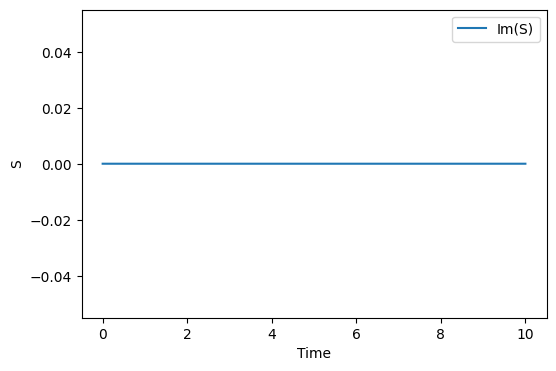

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(time, abs(S), label='Simulated S')
plt.plot(time, np.real(S), label='Re(S)')
plt.plot(time, np.imag(S), label='Im(S)')
plt.xlabel('Time'); plt.ylabel('S')
plt.legend()

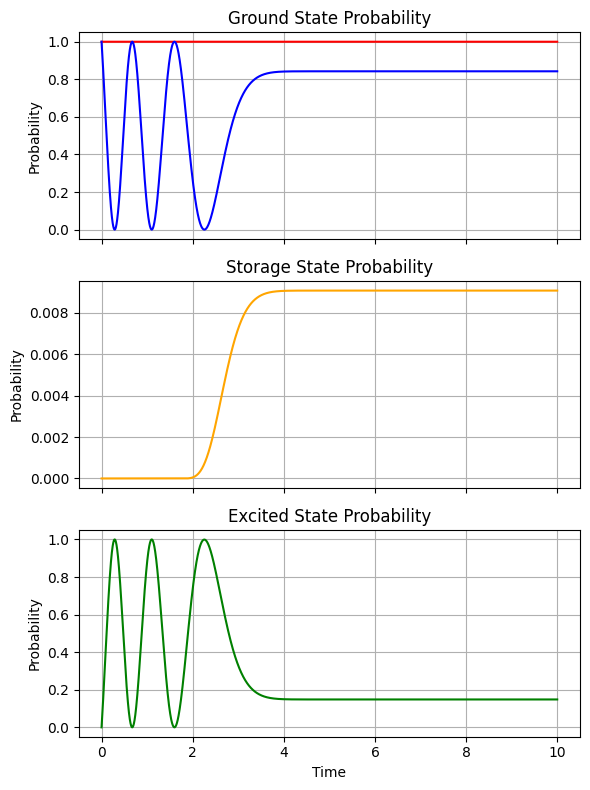

In [146]:
fig, axs = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

# Sanity checks
axs[0].plot(time, prob_g+prob_e+prob_s, color='red')
axs[0].plot(time, prob_g, color='blue')
axs[0].set_ylabel('Probability')
axs[0].set_title('Ground State Probability')
axs[0].grid()

axs[1].plot(time, prob_s, color='orange')
axs[1].set_ylabel('Probability')
axs[1].set_title('Storage State Probability')
axs[1].grid()

axs[2].plot(time, prob_e, color='green')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('Probability')
axs[2].set_title('Excited State Probability')
axs[2].grid()
plt.tight_layout()

### Optimal coupling $\beta(t)$

From Gorshkov's paper, the optimal control pulse shape to store the incoming signal $\alpha_{in}$: 

$$\textbf{g}(t)= -\frac{\gamma(1+C)-i\Delta}{\sqrt{2\gamma(1+C)}} \cdot \frac{\alpha_{in}(t)}{\sqrt{\int_0^T{|\alpha_{in}(t)|^2 dt}}} \cdot
\text{exp} \left(\frac{i \Delta \cdot h(t, T)}{\gamma^2(1+C)^2+\Delta^2} \right)$$


- $h(t, T) = \int_t^T |\textbf{g}(t)|^2 dt$.  What is $T$? Seems to be pulse duration, which here we will simply treat as the end of time array. (integrated phaes accumulation due to AC stark shift. Note that this would become 0 if we rotated into an AC stark shifted frame). There will be discrete time steps in the Hamiltonian due to h(t) integrator. If we can make this more discontinuous at second order rather than first order, the simulation may scale better with time.
- $C$ is cavity cooperativity.
- $\gamma$ is decay rate (of the excited state?)
- $\Delta$ is the detuning of the Raman memory
- $T$ is the duration of the input pulse

We can rewrite this for the code as:

$$ \textbf{g}(t) = a \times b \times \text{exp} \left(\frac{i\Delta h(t, T)}{c}\right)$$
- $a = -\frac{\gamma(1+C)-i\Delta}{\sqrt{2\gamma(1+C)}}$
- $b = \frac{\alpha_{in}(t)}{\sqrt{\int_0^T{|\alpha_{in}(t)|^2dt}}}$
- $c = \gamma^2(1+C)^2+\Delta^2$

Note: could be interesting trying to simulate the Gorshkov Hamiltonian with its 50 terms. Also, when we are computing h, note that $|\textbf{g}(t)|^2$ will be $|a \cdot b|^2$.

In [76]:
gamma = 1.0       # decay rate
C = 2.0           # cooperativity
Delta = 1.0       # detuning

# Precompute prefactors (constants)
a = -(gamma*(1+C) - 1j*Delta) / np.sqrt(2*gamma*(1+C))
c = gamma**2*(1+C)**2 + Delta**2

# Compute b
alpha = alpha_in(time) # array of alpha_in
b = [0]
for i in range(1, len(time)):
    integral_val = integrate.simps(abs(alpha[0:i])**2, time[0:i]) # integral (0 to t) of |alpha|^2
    if (integral_val == 0):
        b.append(0)
    else:      
        b.append(alpha[i] / (np.sqrt(integral_val)))
b = np.array(b)

In [ ]:
# Returns the integral of |g(t)|^2 from t[idx] to t[-1]
def get_h(g, idx, time):
    h_val = integrate.simps(np.abs(g[idx:-1])**2, time[idx:-1]) # Integrate g from time[idx] to time[-1]
    return h_val

In [126]:
g_vals = np.array([0])
h_vals = np.array([0])
for idx in tqdm(range(0, len(time)-1)):
    h = get_h(a*b, idx, time)
    if np.imag(h) != 0: print('Imaginary part detected')
    g_vals = np.append(g_vals, a*b[idx]*np.exp(1j*Delta*h/c))
    h_vals = np.append(h_vals, h)

100%|██████████| 7999/7999 [00:02<00:00, 2751.41it/s]


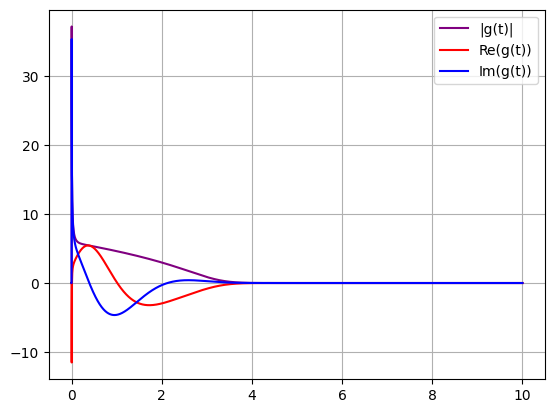

In [133]:
plt.plot(time, abs(g_vals), color='purple', label='|g(t)|')
plt.plot(time, np.real(g_vals), color='red', label='Re(g(t))')
plt.plot(time, np.imag(g_vals), color='blue', label='Im(g(t))')
plt.grid()
plt.legend()